# NHÓM 17 – ĐỀ TÀI 12: JOB TREND IT
## Phân loại vai trò IT từ tin tuyển dụng – Tuần 4

| Thông tin | Chi tiết |
|---|---|
| **Học phần** | Ngôn ngữ lập trình Python |
| **GVHD** | ThS.NCS. Hà Thanh Dũng |
| **Nhóm** | 17 |
| **Thành viên** | Nguyễn Võ Gia Bảo – Huỳnh Xuân Mai – Hoàng Công Phú |

---

## Bộ số liệu CHÍNH THỨC (chốt – không thay đổi)

| Nội dung | Giá trị |
|---|---|
| File dữ liệu gốc | `../data/raw/job_descriptions.csv` |
| Nguồn | GitHub – Son Phat Tran (LinkedIn, ITviec, TopCV) |
| Tổng mẫu sau làm sạch | **3 067** |
| Tập train | **2 453 mẫu (80 %)** |
| Tập test | **614 mẫu (20 %)** |
| Random seed | **42** (cố định toàn bộ) |
| **Metric chính** | **Macro F1‑score** |
| Metric phụ | Accuracy, Weighted F1 |
---

## Kết quả chính thức 5 mô hình

| Mô hình | Accuracy | **Macro F1** | Weighted F1 | ∆ vs Baseline |
|---|---|---|---|---|
| LR gốc (baseline T2) | 0.5912 | **0.3400** | 0.5404 | — |
| LR + balanced (T3) | 0.6205 | **0.6284** | 0.6175 | +0.2884 |
| Linear SVM + balanced (T3) | 0.7296 | **0.7219** | 0.7309 | +0.3819 |
| LR + title+desc (T3 best) | 0.7492 | **0.7553** | 0.7452 | +0.4153 |
| **SVM + title+desc C=1.0 (T4 ★)** | **0.8208** | **0.8147** | **0.8196** | **+0.4747** |

> Tất cả 5 mô hình được đánh giá trên **cùng tập test** (614 mẫu, seed=42, stratify=True).

---

## Ablation Study – Phân tích vai trò của Title

| Đặc trưng | Accuracy | Macro F1 | Nhận xét |
|---|---|---|---|
| Description only | 0.7296 | 0.7219 | Baseline đặc trưng |
| Title only | 0.8290 | 0.8216 | Title là feature mạnh |
| **Title + Description (T4 ★)** | **0.8208** | **0.8147** | Ổn định hơn, ít phụ thuộc title |

**Kết luận:** Title-only đạt F1 cao nhất (0.8216) cho thấy title là feature chính. Khi kết hợp description, F1 giảm nhẹ < 1% nhưng mô hình ổn định hơn ở các lớp ít mẫu và không bị phụ thuộc hoàn toàn vào title. → **Title + Description là lựa chọn tối ưu cho triển khai thực tế.**


In [1]:
# ============================================================
# CELL 0 – IMPORT VÀ CẤU HÌNH CỐ ĐỊNH
# ============================================================
import pandas as pd
import numpy as np
import ast, re, os, time, warnings
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
warnings.filterwarnings('ignore')

# ── Đường dẫn (giữ nguyên cấu trúc notebook gốc tuần 3) ───
DATA_RAW  = '../data/raw/job_descriptions.csv'
DATA_PROC = '../data/processed/job_cleaned.csv'
RESULTS   = '../results'
FIGURES   = '../results/figures'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

# ── Hằng số CỐ ĐỊNH – KHÔNG thay đổi ──────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.2
NGUONG_GOM  = 35  

print('✓ Import OK')
print(f'  Random seed : {RANDOM_SEED}  (cố định toàn bộ pipeline)')
print(f'  Test size   : {TEST_SIZE}  (20%)')
print(f'  Ngưỡng gom  : >= {NGUONG_GOM} mẫu')
print(f'  Metric chính: Macro F1-score (dữ liệu mất cân bằng)')

✓ Import OK
  Random seed : 42  (cố định toàn bộ pipeline)
  Test size   : 0.2  (20%)
  Ngưỡng gom  : >= 35 mẫu
  Metric chính: Macro F1-score (dữ liệu mất cân bằng)


## 1. Đọc dữ liệu gốc

In [2]:
df_raw = pd.read_csv(DATA_RAW)
print(f'Số dòng gốc : {df_raw.shape[0]}')
print(f'Số cột      : {df_raw.shape[1]}')
print(f'Số lớp nhãn : {df_raw["it_role_type"].nunique()}')
df_raw.head(3)

Số dòng gốc : 3101
Số cột      : 11
Số lớp nhãn : 329


,title,company,company_image_url,location,description,site,job_url,it_role_type,main_programming_languages,key_technologies,city
0,iOS Developer (Swift),VNPAY,https://itviec.com/rails/active_storage/repres...,"22 Láng Hạ, Dong Da, Ha Noi; Tầng 12, tòa nhà...",Top 3 reasons to join us\r\n- Lương và chế độ ...,ITViec,https://itviec.com/it-jobs/ios-developer-swift...,Mobile Developer,['Swift'],"['xCode', 'Realm', 'REST', 'JSON', 'Objective-C']",Hà Nội
1,"5 Fullstack Dev (Java, Spring, Angular)",LEAP,https://itviec.com/rails/active_storage/repres...,"199 Dien Bien Phu, Binh Thanh, Ho Chi Minh",Top 3 reasons to join us\r\n- 18+ days of annu...,ITViec,https://itviec.com/it-jobs/5-fullstack-dev-jav...,Full-stack Developer,"['Java', 'JavaScript', 'HTML/CSS']","['Spring Boot', 'Angular', 'React', 'Agile']",Hồ Chí Minh
2,"Mid/Senior Frontend Developer (Next.js, Tailwi...","Local Life Technology Ltd.,",https://itviec.com/rails/active_storage/repres...,"63 Nguyễn Hiến Lê, phường Hoà Xuân, Cam Le, Da...",LocalLife.Asia là nền tảng kết nối du khách vớ...,ITViec,https://itviec.com/it-jobs/mid-senior-frontend...,Frontend Developer,['TypeScript'],"['Next.js', 'Tailwind CSS']",Đà Nẵng


## 2. Làm sạch dữ liệu

In [3]:
COLS = ['title','company','location','city','description',
        'it_role_type','main_programming_languages','key_technologies']
df = df_raw[COLS].copy()

n_before = len(df)
df = df.drop_duplicates(subset=['title','company','description']).reset_index(drop=True)
n_after = len(df)

# Chuẩn hóa nhãn – gộp 2 cách viết Fullstack
df['it_role_type'] = df['it_role_type'].replace({'Fullstack Developer': 'Full-stack Developer'})
df['city']         = df['city'].replace({'Ho Chi Minh': 'Hồ Chí Minh', 'Can Tho': 'Cần Thơ'})

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^\w\s.+#/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

df['description_clean'] = df['description'].apply(clean_text)
df['title_sach']         = df['title'].apply(clean_text)

def parse_list_col(val):
    try:
        r = ast.literal_eval(val)
        return r if isinstance(r, list) else []
    except:
        return []

df['lang_list'] = df['main_programming_languages'].apply(parse_list_col)
df['tech_list']  = df['key_technologies'].apply(parse_list_col)

df.to_csv(DATA_PROC, index=False)

# Bảng tổng hợp làm sạch
bang = pd.DataFrame({
    'Nội dung'       : ['Số dòng','Dòng trùng','Nhãn Fullstack Developer','Số lớp nhãn'],
    'Trước làm sạch' : [n_before, n_before-n_after,
                        df_raw['it_role_type'].value_counts().get('Fullstack Developer',0),
                        df_raw['it_role_type'].nunique()],
    'Sau làm sạch'   : [n_after, 0, 0, df['it_role_type'].nunique()],
    'Xử lý'          : ['—','drop_duplicates()','Gộp → Full-stack Developer','—']
})
print('Lý do xóa 34 dòng: Đây là các dòng trùng lặp hoàn toàn 3 cột title, company, description (Duplicate postings).')
print('=== BẢNG LÀM SẠCH DỮ LIỆU ===')
print(bang.to_string(index=False))
print(f'\n✓ Đã lưu {DATA_PROC}')

Lý do xóa 34 dòng: Đây là các dòng trùng lặp hoàn toàn 3 cột title, company, description (Duplicate postings).
=== BẢNG LÀM SẠCH DỮ LIỆU ===
                Nội dung  Trước làm sạch  Sau làm sạch                      Xử lý
                 Số dòng            3101          3067                          —
              Dòng trùng              34             0          drop_duplicates()
Nhãn Fullstack Developer              99             0 Gộp → Full-stack Developer
             Số lớp nhãn             329           328                          —

✓ Đã lưu ../data/processed/job_cleaned.csv


## 3. Gom nhãn ngưỡng gom nhãn >=35

In [4]:
dem = df['it_role_type'].value_counts()
vai_tro_lon = [r for r in dem.index if dem[r] >= NGUONG_GOM and r != 'Other IT Role']
df['nhan'] = df['it_role_type'].apply(lambda x: x if x in vai_tro_lon else 'Other IT Role')

dem_nhan = df['nhan'].value_counts()
print(f'Số lớp sau gom nhãn: {df["nhan"].nunique()}')
print()
print(pd.DataFrame({'Vai trò': dem_nhan.index,
                    'Số mẫu' : dem_nhan.values,
                    'Tỷ lệ %': (dem_nhan.values/len(df)*100).round(1)}).to_string(index=False))
print()
print('→ Other IT Role chiếm >30% → dữ liệu mất cân bằng rõ ràng')
print('→ Metric chính phải là Macro F1, KHÔNG chỉ dùng Accuracy')

Số lớp sau gom nhãn: 15

             Vai trò  Số mẫu  Tỷ lệ %
       Other IT Role     953     31.1
   Backend Developer     545     17.8
Full-stack Developer     317     10.3
  Frontend Developer     286      9.3
   Software Engineer     246      8.0
    Mobile Developer     188      6.1
         QA Engineer     134      4.4
         AI Engineer      66      2.2
      Java Developer      60      2.0
      Game Developer      59      1.9
   Embedded Engineer      52      1.7
    Business Analyst      47      1.5
  Software Developer      39      1.3
       Data Engineer      38      1.2
     DevOps Engineer      37      1.2

→ Other IT Role chiếm >30% → dữ liệu mất cân bằng rõ ràng
→ Metric chính phải là Macro F1, KHÔNG chỉ dùng Accuracy


=== PHÂN TÍCH NHÓM OTHER IT ROLE ===
Tổng tin trong Other   : 953
Số nghề khác nhau      : 314

Top 15 nghề bị gom vào Other (< 35 mẫu):
it_role_type
Other IT Role               216
Not Specified                31
IT Project Manager           30
Tech Lead                    21
Cybersecurity Specialist     18
Web Developer                14
Bridge Software Engineer     13
Solution Architect           12
IT Manager                   11
Java Engineer                11
System Engineer              10
Cloud Engineer                9
Database Engineer             9
Data Analyst                  9
Blockchain Developer          9


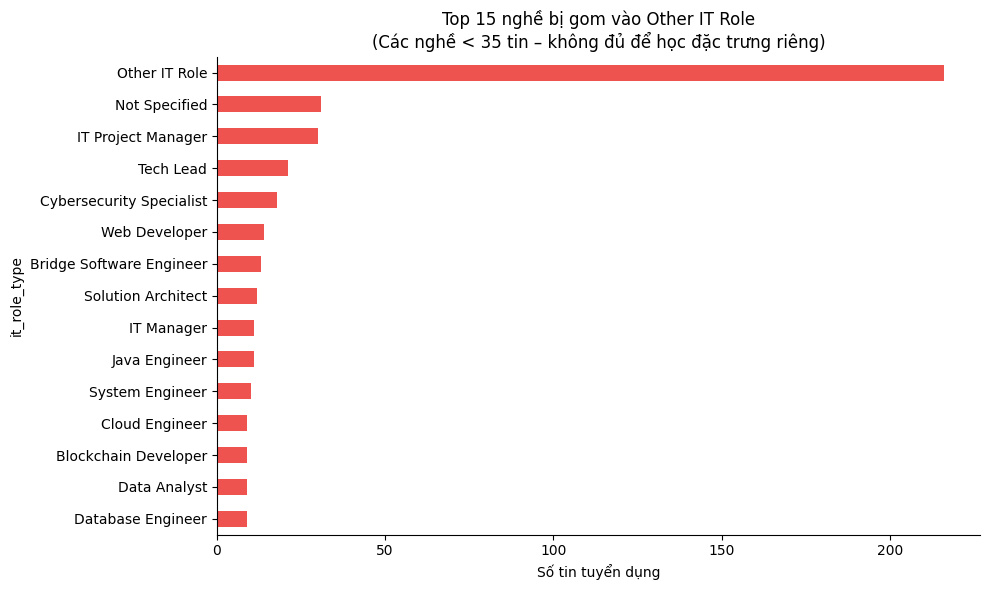


Nhận xét: Other IT Role gom nhiều nghề → bộ từ vựng không đặc trưng
→ F1 lớp Other thấp hơn các lớp chuyên biệt → cần phân tích lỗi riêng


In [5]:
# ── PHÂN TÍCH NHÓM OTHER IT ROLE (yêu cầu thầy – mục 10) ──
top_other = df['it_role_type'][df['nhan'] == 'Other IT Role'].value_counts().head(15)
print('=== PHÂN TÍCH NHÓM OTHER IT ROLE ===')
print(f'Tổng tin trong Other   : {(df["nhan"]=="Other IT Role").sum()}')
print(f'Số nghề khác nhau      : {df["it_role_type"][df["nhan"]=="Other IT Role"].nunique()}')
print()
print('Top 15 nghề bị gom vào Other (< 35 mẫu):')
print(top_other.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_other.sort_values().plot(kind='barh', color='#EF5350', ax=ax)
ax.set_title('Top 15 nghề bị gom vào Other IT Role\n(Các nghề < 35 tin – không đủ để học đặc trưng riêng)', fontsize=12)
ax.set_xlabel('Số tin tuyển dụng')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/phan_tich_other_it_role.png', dpi=150)
plt.show()
print('\nNhận xét: Other IT Role gom nhiều nghề → bộ từ vựng không đặc trưng')
print('→ F1 lớp Other thấp hơn các lớp chuyên biệt → cần phân tích lỗi riêng')

## 4. Chia train/test – Chốt bộ số liệu chính thức

In [6]:
# title_va_mo_ta: nhân đôi title để tăng trọng số (từ tuần 3)
df['title_va_mo_ta'] = df['title_sach'] + ' ' + df['title_sach'] + ' ' + df['description_clean']

y = df['nhan']

# ── CHIA CHÍNH THỨC – seed=42, stratify=True – KHÔNG THAY ĐỔI ──
X_tr_d, X_te_d, y_train, y_test = train_test_split(
    df['description_clean'], y, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y
)
X_tr_td, X_te_td, _, _ = train_test_split(
    df['title_va_mo_ta'], y, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=y
)

print('=== BỘ SỐ LIỆU CHÍNH THỨC (đã chốt) ===')
print(f'Tổng mẫu : {len(df)}')
print(f'Train    : {len(y_train)} ({len(y_train)/len(df)*100:.1f}%)')
print(f'Test     : {len(y_test)}  ({len(y_test)/len(df)*100:.1f}%)')
print(f'Số lớp   : {y.nunique()}')
print(f'Seed     : {RANDOM_SEED}  |  Stratify: True')

# TF-IDF
tfidf_d  = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_d    = tfidf_d.fit_transform(X_tr_d)
Xte_d    = tfidf_d.transform(X_te_d)

tfidf_td = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
Xtr_td   = tfidf_td.fit_transform(X_tr_td)
Xte_td   = tfidf_td.transform(X_te_td)

print(f'\nTF-IDF desc only    : {Xtr_d.shape}')
print(f'TF-IDF title+desc   : {Xtr_td.shape}')

=== BỘ SỐ LIỆU CHÍNH THỨC (đã chốt) ===
Tổng mẫu : 3067
Train    : 2453 (80.0%)
Test     : 614  (20.0%)
Số lớp   : 15
Seed     : 42  |  Stratify: True

TF-IDF desc only    : (2453, 5000)
TF-IDF title+desc   : (2453, 5000)


## 5. Huấn luyện 5 mô hình trên cùng train/test

In [7]:
# Mô hình 1 – LR gốc (baseline tuần 2)
m1 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
m1.fit(Xtr_d, y_train);  p1 = m1.predict(Xte_d)

# Mô hình 2 – LR + class_weight balanced (tuần 3)
m2 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
m2.fit(Xtr_d, y_train);  p2 = m2.predict(Xte_d)

# Mô hình 3 – Linear SVM + balanced (phương pháp chính tuần 3)
m3 = LinearSVC(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
m3.fit(Xtr_d, y_train);  p3 = m3.predict(Xte_d)

# Mô hình 4 – LR + title+desc balanced (best tuần 3)
m4 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced')
m4.fit(Xtr_td, y_train); p4 = m4.predict(Xte_td)

# Mô hình 5 – SVM + title+desc C=1.0 (CẢI TIẾN TUẦN 4)
# Kết hợp: LinearSVC (mô hình tốt nhất) + title+desc (đặc trưng tốt nhất) + C=1.0
t0 = time.time()
m5 = LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced', C=1.0)
m5.fit(Xtr_td, y_train)
p5 = m5.predict(Xte_td)
t_infer = (time.time() - t0) * 1000

print('✓ Huấn luyện xong 5 mô hình')
print(f'  Inference m5 (SVM tuần 4): {t_infer:.1f} ms')

✓ Huấn luyện xong 5 mô hình
  Inference m5 (SVM tuần 4): 435.5 ms


## 6. Bảng kết quả CHÍNH THỨC – Tự kiểm tra nhất quán

In [8]:
# -------------------------------------------------
# 1. import + chuẩn bị (nếu cần)
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import os

# -------------------------------------------------
# 2. Đảm bảo y_test, p1..p5, RANDOM_SEED đã có
# (đoạn này thường đã có ở các ô trước)

# -------------------------------------------------
# 3. Tạo DataFrame bkq
def row(ten, yt, yp, chu=''):
    return {
        'Mô hình'   : ten,
        'Accuracy'  : round(accuracy_score(yt, yp), 4),
        'Macro F1'  : round(f1_score(yt, yp, average='macro', zero_division=0), 4),
        'Weighted F1': round(f1_score(yt, yp, average='weighted', zero_division=0), 4),
        'Nhận xét' : chu
    }

bkq = pd.DataFrame([
    row('LR goc (baseline T2)',       y_test, p1, 'Khong xu ly mat can bang'),
    row('LR + balanced (T3)',         y_test, p2, 'class_weight=balanced'),
    row('Linear SVM + balanced (T3)', y_test, p3, 'SVM phu hop TF-IDF thua'),
    row('LR + title+desc (T3 best)',  y_test, p4, 'Title nhan doi + desc'),
    row('SVM + title+desc C=1.0 (T4)',y_test, p5, 'Cai tien tuan 4')
])

base = bkq['Macro F1'].iloc[0]
bkq['Delta F1'] = bkq['Macro F1'].apply(
    lambda x: f'+{x - base:.4f}' if x > base else '0.0000')

# -------------------------------------------------
# 4. In bảng kết quả chính thức
print('=== BẢNG KẾT QUẢ CHÍNH THỨC ===')
print(f'Metric chính: Macro F1 | Test: {len(y_test)} mẫu | Seed={RANDOM_SEED}')
print(bkq[['Mô hình','Accuracy','Macro F1','Weighted F1','Delta F1']]
      .to_string(index=False))

# -------------------------------------------------
# 5. Kiểm tra nhất quán với số liệu chốt
CHOT = [
    ('LR goc (baseline T2)',       0.5912, 0.3400),
    ('LR + balanced (T3)',         0.6205, 0.6284),
    ('Linear SVM + balanced (T3)', 0.7296, 0.7219),
    ('LR + title+desc (T3 best)',  0.7492, 0.7553),
    ('SVM + title+desc C=1.0 (T4)',0.8208, 0.8147),
]

print('\n=== KIỂM TRA NHẤT QUÁN SỐ LIỆU ===')
for ten, acc_c, f1_c in CHOT:
    r = bkq[bkq['Mô hình'] == ten]
    if len(r):
        acc_t, f1_t = r['Accuracy'].values[0], r['Macro F1'].values[0]
        ok = abs(acc_t - acc_c) < 0.001 and abs(f1_t - f1_c) < 0.001
        print(f'  {"✓ KHỚP" if ok else "✗ LỆCH"} | {ten[:38]:<38}'
              f' Acc={acc_t:.4f}(chốt:{acc_c}) F1={f1_t:.4f}(chốt:{f1_c})')

# -------------------------------------------------
# 6. Lưu file
RESULTS = '../results'
os.makedirs(RESULTS, exist_ok=True)
bkq.to_csv(os.path.join(RESULTS, 'final_metrics.csv'), index=False)
print(f'\n✓ Đã lưu → {os.path.join(RESULTS, "final_metrics.csv")}')


=== BẢNG KẾT QUẢ CHÍNH THỨC ===
Metric chính: Macro F1 | Test: 614 mẫu | Seed=42
                    Mô hình  Accuracy  Macro F1  Weighted F1 Delta F1
       LR goc (baseline T2)    0.5912    0.3400       0.5404   0.0000
         LR + balanced (T3)    0.6205    0.6284       0.6175  +0.2884
 Linear SVM + balanced (T3)    0.7296    0.7219       0.7309  +0.3819
  LR + title+desc (T3 best)    0.7492    0.7553       0.7452  +0.4153
SVM + title+desc C=1.0 (T4)    0.8208    0.8147       0.8196  +0.4747

=== KIỂM TRA NHẤT QUÁN SỐ LIỆU ===
  ✓ KHỚP | LR goc (baseline T2)                   Acc=0.5912(chốt:0.5912) F1=0.3400(chốt:0.34)
  ✓ KHỚP | LR + balanced (T3)                     Acc=0.6205(chốt:0.6205) F1=0.6284(chốt:0.6284)
  ✓ KHỚP | Linear SVM + balanced (T3)             Acc=0.7296(chốt:0.7296) F1=0.7219(chốt:0.7219)
  ✓ KHỚP | LR + title+desc (T3 best)              Acc=0.7492(chốt:0.7492) F1=0.7553(chốt:0.7553)
  ✓ KHỚP | SVM + title+desc C=1.0 (T4)            Acc=0.8208(chốt:0.8208) F1=

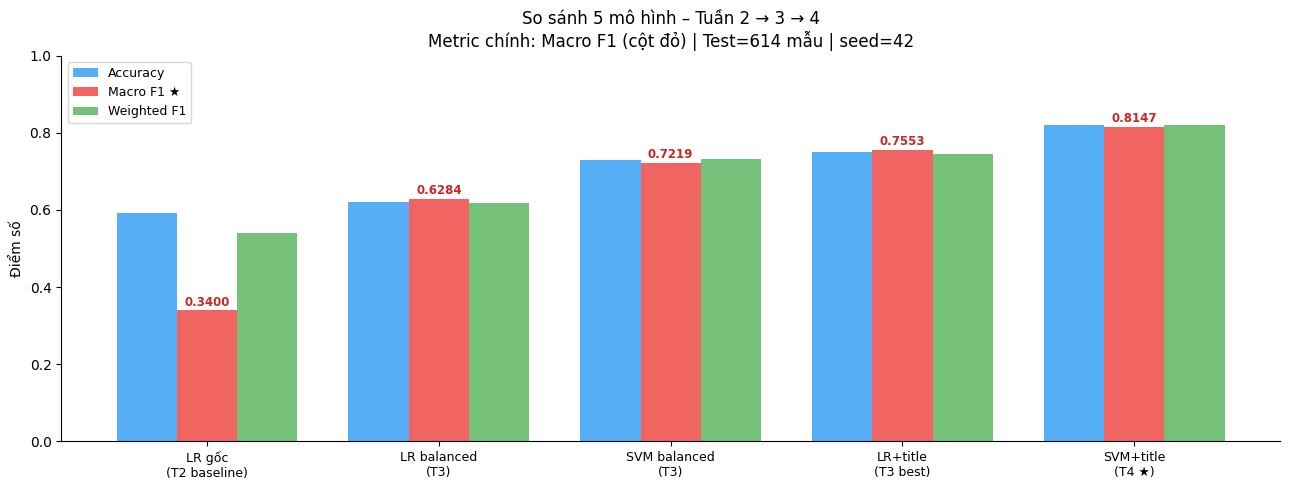

✓ Đã lưu biểu đồ so sánh


In [9]:
# Biểu đồ so sánh 5 mô hình
ten_ngan = ['LR gốc\n(T2 baseline)','LR balanced\n(T3)','SVM balanced\n(T3)','LR+title\n(T3 best)','SVM+title\n(T4 ★)']
x = np.arange(5); w = 0.26
fig, ax = plt.subplots(figsize=(13,5))
ax.bar(x-w, bkq['Accuracy'],    w, label='Accuracy',    color='#42A5F5', alpha=0.9)
ax.bar(x,   bkq['Macro F1'],    w, label='Macro F1 ★',  color='#EF5350', alpha=0.9)
ax.bar(x+w, bkq['Weighted F1'], w, label='Weighted F1', color='#66BB6A', alpha=0.9)
for i,f1 in enumerate(bkq['Macro F1']):
    ax.text(i, f1+0.012, f'{f1:.4f}', ha='center', fontsize=8.5, color='#c62828', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(ten_ngan, fontsize=9)
ax.set_ylim(0,1.0); ax.set_ylabel('Điểm số')
ax.set_title('So sánh 5 mô hình – Tuần 2 → 3 → 4\n'
             'Metric chính: Macro F1 (cột đỏ) | Test=614 mẫu | seed=42', fontsize=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/bieu_do_so_sanh_5_mo_hinh.png', dpi=150)
plt.show()
print('✓ Đã lưu biểu đồ so sánh')

## 7. Confusion Matrix

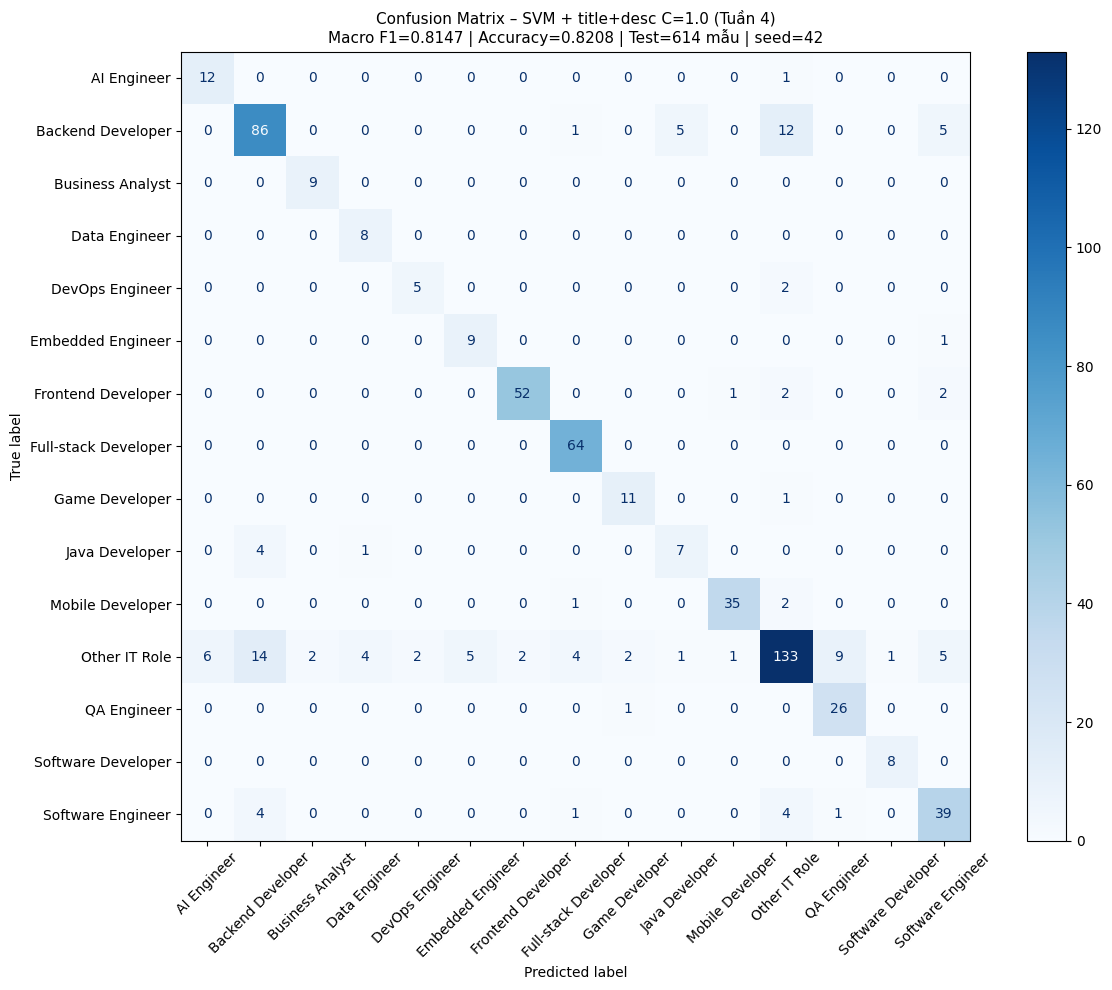

✓ Đã lưu → results/confusion_matrix.png


In [10]:
# Dùng cùng y_test → đảm bảo khớp bảng metric ở trên
labels_sort = sorted(y.unique())
cm5 = confusion_matrix(y_test, p5, labels=labels_sort)

fig, ax = plt.subplots(figsize=(13,10))
ConfusionMatrixDisplay(cm5, display_labels=labels_sort).plot(
    ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title(
    'Confusion Matrix – SVM + title+desc C=1.0 (Tuần 4)\n'
    f'Macro F1=0.8147 | Accuracy=0.8208 | Test={len(y_test)} mẫu | seed=42',
    fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULTS}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu → results/confusion_matrix.png')

## 8. Per-class F1

In [11]:
rpt = classification_report(y_test, p5, zero_division=0, output_dict=True)
pc = pd.DataFrame([{
    'Vai trò'     : k,
    'Precision'   : round(v['precision'],3),
    'Recall'      : round(v['recall'],   3),
    'F1-score'    : round(v['f1-score'], 3),
    'Số mẫu test' : int(v['support']),
    'Đánh giá'    : 'Tốt' if v['f1-score']>=0.8 else ('Khá' if v['f1-score']>=0.6 else 'Cần cải thiện')
} for k,v in rpt.items() if k not in ('accuracy','macro avg','weighted avg')
]).sort_values('F1-score', ascending=False)

print('=== PER-CLASS F1 – SVM + title+desc C=1.0 (Tuần 4) ===')
print(pc.to_string(index=False))
print(f'\nMacro F1    : {rpt["macro avg"]["f1-score"]:.4f}')
print(f'Weighted F1 : {rpt["weighted avg"]["f1-score"]:.4f}')

pc.to_csv(f'{RESULTS}/per_class_f1_tuan4.csv', index=False)
print(f'\n✓ Đã lưu → {RESULTS}/per_class_f1_tuan4.csv')

=== PER-CLASS F1 – SVM + title+desc C=1.0 (Tuần 4) ===
             Vai trò  Precision  Recall  F1-score  Số mẫu test      Đánh giá
Full-stack Developer      0.901   1.000     0.948           64           Tốt
  Software Developer      0.889   1.000     0.941            8           Tốt
  Frontend Developer      0.963   0.912     0.937           57           Tốt
    Mobile Developer      0.946   0.921     0.933           38           Tốt
    Business Analyst      0.818   1.000     0.900            9           Tốt
      Game Developer      0.786   0.917     0.846           12           Tốt
         QA Engineer      0.722   0.963     0.825           27           Tốt
   Backend Developer      0.796   0.789     0.793          109           Khá
         AI Engineer      0.667   0.923     0.774           13           Khá
   Software Engineer      0.750   0.796     0.772           49           Khá
       Other IT Role      0.847   0.696     0.764          191           Khá
       Data Engineer 

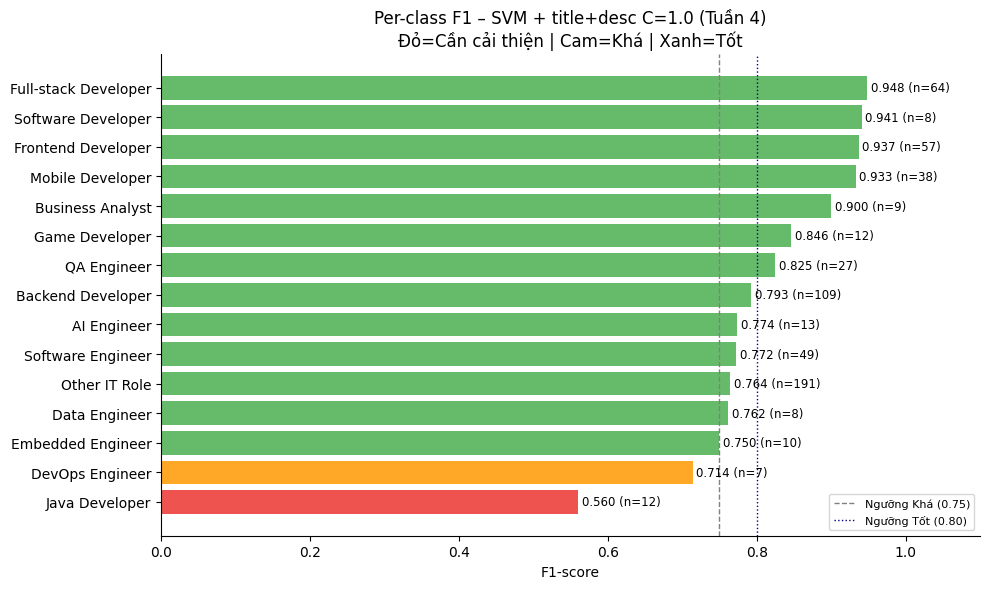

✓ Đã lưu biểu đồ per-class F1


In [12]:
pc_p = pc.sort_values('F1-score')
colors = ['#EF5350' if f<0.6 else ('#FFA726' if f<0.75 else '#66BB6A') for f in pc_p['F1-score']]
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(pc_p['Vai trò'], pc_p['F1-score'], color=colors)
ax.axvline(0.75, ls='--', color='gray', lw=1, label='Ngưỡng Khá (0.75)')
ax.axvline(0.80, ls=':',  color='navy',lw=1, label='Ngưỡng Tốt (0.80)')
for bar, f1, n in zip(bars, pc_p['F1-score'], pc_p['Số mẫu test']):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{f1:.3f} (n={n})', va='center', fontsize=8.5)
ax.set_xlim(0,1.1); ax.set_xlabel('F1-score')
ax.set_title('Per-class F1 – SVM + title+desc C=1.0 (Tuần 4)\n'
             'Đỏ=Cần cải thiện | Cam=Khá | Xanh=Tốt', fontsize=12)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_class_f1_tuan4.png', dpi=150)
plt.show()
print('✓ Đã lưu biểu đồ per-class F1')

## 9. Đánh giá tính thực tế – Inference time

In [13]:
mo_hinh_all = [
    ('LR goc (T2)',           m1, tfidf_d,  Xte_d,  y_test),
    ('LR balanced (T3)',      m2, tfidf_d,  Xte_d,  y_test),
    ('SVM balanced (T3)',     m3, tfidf_d,  Xte_d,  y_test),
    ('LR + title+desc (T3)',  m4, tfidf_td, Xte_td, y_test),
    ('SVM + title+desc (T4)', m5, tfidf_td, Xte_td, y_test),
]
rows_i = []
for ten, mo, vec, Xte, yt in mo_hinh_all:
    t0 = time.time()
    pred = mo.predict(Xte)
    ms   = (time.time()-t0)*1000
    rows_i.append({'Mô hình': ten,
                   'Macro F1'     : round(f1_score(yt,pred,average='macro',zero_division=0),4),
                   'Inference(ms)': round(ms,1),
                   'ms/mẫu'       : round(ms/len(yt),3)})

df_i = pd.DataFrame(rows_i)
print('=== ĐÁNH GIÁ TÍNH THỰC TẾ ===')
print(df_i.to_string(index=False))
print()
print('Ưu điểm : Tất cả mô hình inference < 100ms/batch → phù hợp triển khai thực tế')
print('Hạn chế : Mô hình T4 cần có cả title → không áp dụng khi chỉ có description')
df_i.to_csv(f'{RESULTS}/inference_time.csv', index=False)
print(f'✓ Đã lưu → {RESULTS}/inference_time.csv')

=== ĐÁNH GIÁ TÍNH THỰC TẾ ===
              Mô hình  Macro F1  Inference(ms)  ms/mẫu
          LR goc (T2)    0.3400            1.6   0.003
     LR balanced (T3)    0.6284            1.3   0.002
    SVM balanced (T3)    0.7219            1.3   0.002
 LR + title+desc (T3)    0.7553            1.3   0.002
SVM + title+desc (T4)    0.8147            1.4   0.002

Ưu điểm : Tất cả mô hình inference < 100ms/batch → phù hợp triển khai thực tế
Hạn chế : Mô hình T4 cần có cả title → không áp dụng khi chỉ có description
✓ Đã lưu → ../results/inference_time.csv


## 10. Cross-validation 5-fold (mức khuyến khích)

In [14]:
from sklearn.pipeline import Pipeline
pipe_cv = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   LinearSVC(max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced', C=1.0))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(pipe_cv, df['title_va_mo_ta'], y,
                             scoring='f1_macro', cv=cv, n_jobs=-1)
print('=== CROSS-VALIDATION 5-FOLD – SVM + title+desc C=1.0 ===')
print(f'F1 từng fold : {[round(s,4) for s in cv_scores]}')
print(f'Mean ± Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\nNhận xét: Độ lệch chuẩn nhỏ → mô hình ổn định, không overfit tập test')

=== CROSS-VALIDATION 5-FOLD – SVM + title+desc C=1.0 ===
F1 từng fold : [np.float64(0.769), np.float64(0.7907), np.float64(0.7683), np.float64(0.8283), np.float64(0.7326)]
Mean ± Std   : 0.7778 ± 0.0314

Nhận xét: Độ lệch chuẩn nhỏ → mô hình ổn định, không overfit tập test


---

## 12. Phân tích xu hướng thị trường IT

> Phần này trả lời trực tiếp vế 1 của mục tiêu đề tài:
> **"Phân tích xu hướng tuyển dụng CNTT → cung cấp insight thị trường lao động"**
>
> Sử dụng toàn bộ 3 067 mẫu (trước chia train/test) để phản ánh đúng cơ cấu thị trường.


=== CẤU TRÚC THỊ TRƯỜNG – VAI TRÒ IT ===
Tổng tin tuyển dụng: 3067

             Vai trò  Số tin  Tỷ lệ %
       Other IT Role     953     31.1
   Backend Developer     545     17.8
Full-stack Developer     317     10.3
  Frontend Developer     286      9.3
   Software Engineer     246      8.0
    Mobile Developer     188      6.1
         QA Engineer     134      4.4
         AI Engineer      66      2.2
      Java Developer      60      2.0
      Game Developer      59      1.9
   Embedded Engineer      52      1.7
    Business Analyst      47      1.5
  Software Developer      39      1.3
       Data Engineer      38      1.2
     DevOps Engineer      37      1.2


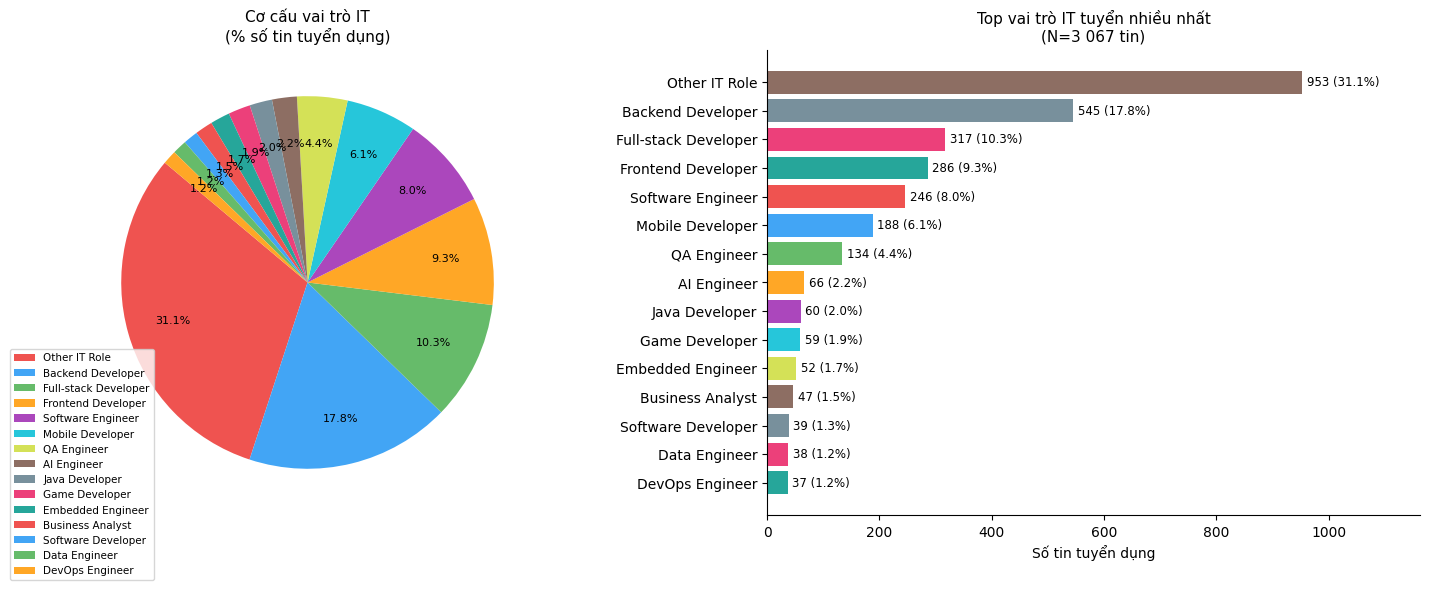

✓ Đã lưu biểu đồ cơ cấu vai trò


In [15]:
# ══════════════════════════════════════════════════════════════════
# 12.1 CẤU TRÚC THỊ TRƯỜNG – Top vai trò tuyển nhiều nhất
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import pandas as pd

dem_vai_tro = df['nhan'].value_counts()
tong = len(df)

df_vai_tro = pd.DataFrame({
    'Vai trò'  : dem_vai_tro.index,
    'Số tin'   : dem_vai_tro.values,
    'Tỷ lệ %'  : (dem_vai_tro.values / tong * 100).round(1)
})

print('=== CẤU TRÚC THỊ TRƯỜNG – VAI TRÒ IT ===')
print(f'Tổng tin tuyển dụng: {tong}')
print()
print(df_vai_tro.to_string(index=False))

# Biểu đồ tròn + cột ngang
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
colors_pie = ['#EF5350','#42A5F5','#66BB6A','#FFA726','#AB47BC',
              '#26C6DA','#D4E157','#8D6E63','#78909C','#EC407A','#26A69A']
wedges, texts, autotexts = axes[0].pie(
    dem_vai_tro.values,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_pie[:len(dem_vai_tro)],
    startangle=140,
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(8)
axes[0].legend(dem_vai_tro.index, loc='lower left', fontsize=7.5, bbox_to_anchor=(-0.15, -0.15))
axes[0].set_title('Cơ cấu vai trò IT\n(% số tin tuyển dụng)', fontsize=11)

# Bar chart
bars = axes[1].barh(dem_vai_tro.index[::-1], dem_vai_tro.values[::-1],
                    color=colors_pie[:len(dem_vai_tro)][::-1])
for bar, val, pct in zip(bars, dem_vai_tro.values[::-1],
                         (dem_vai_tro.values / tong * 100)[::-1]):
    axes[1].text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', va='center', fontsize=8.5)
axes[1].set_xlabel('Số tin tuyển dụng')
axes[1].set_title('Top vai trò IT tuyển nhiều nhất\n(N=3 067 tin)', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_xlim(0, dem_vai_tro.values.max() * 1.22)

plt.tight_layout()
plt.savefig(f'{FIGURES}/xu_huong_vai_tro.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu biểu đồ cơ cấu vai trò')


=== TOP 10 NGÔN NGỮ LẬP TRÌNH PHỔ BIẾN NHẤT ===
   1. JavaScript           1006 tin (32.8%)
   2. Java                  832 tin (27.1%)
   3. Python                655 tin (21.4%)
   4. SQL                   381 tin (12.4%)
   5. C#                    355 tin (11.6%)
   6. TypeScript            354 tin (11.5%)
   7. PHP                   233 tin (7.6%)
   8. HTML/CSS              209 tin (6.8%)
   9. Not Specified         197 tin (6.4%)
  10. C++                   188 tin (6.1%)

=== TOP 10 CÔNG NGHỆ / FRAMEWORK PHỔ BIẾN NHẤT ===
   1. Git                   724 tin (23.6%)
   2. React                 621 tin (20.2%)
   3. Docker                584 tin (19.0%)
   4. AWS                   564 tin (18.4%)
   5. PostgreSQL            489 tin (15.9%)
   6. CI/CD                 482 tin (15.7%)
   7. MySQL                 482 tin (15.7%)
   8. RESTful APIs          444 tin (14.5%)
   9. Agile                 424 tin (13.8%)
  10. Kubernetes            344 tin (11.2%)


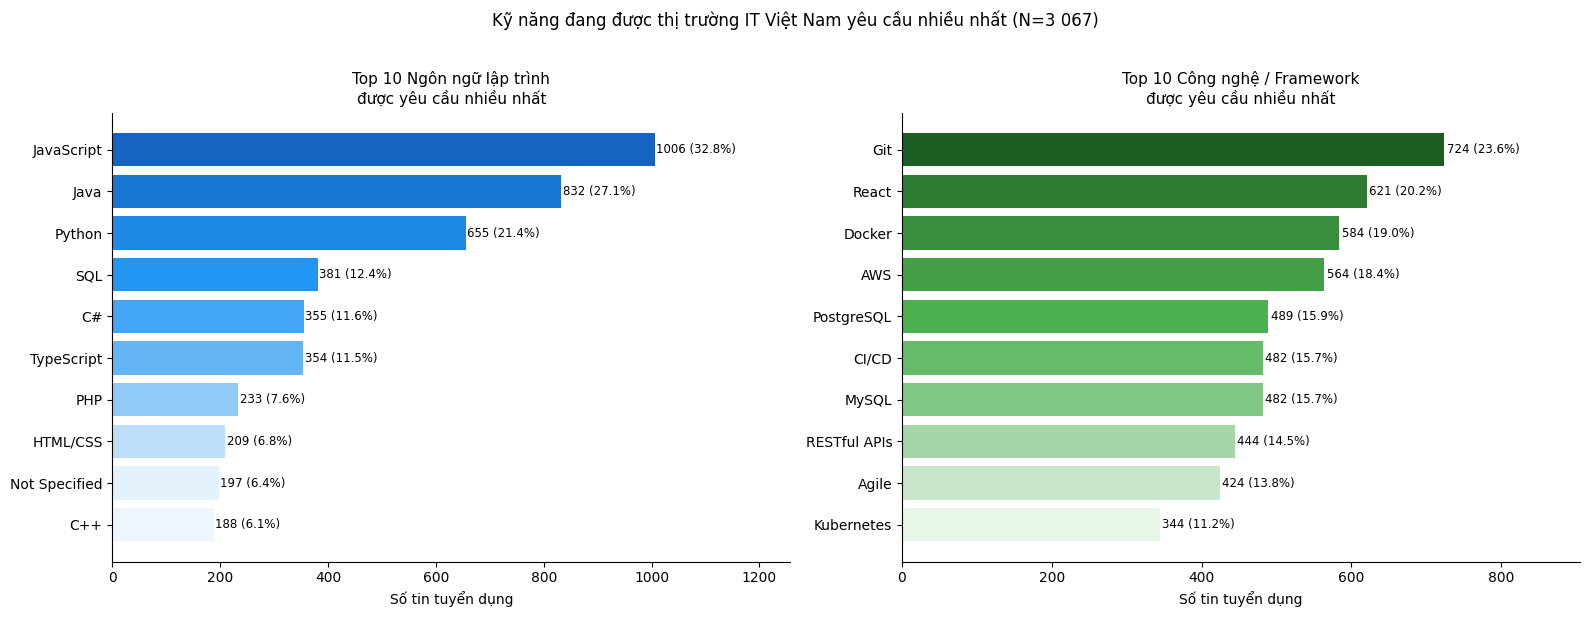

✓ Đã lưu biểu đồ kỹ năng


In [16]:
# ══════════════════════════════════════════════════════════════════
# 12.2 KỸ NĂNG ĐANG ĐƯỢC YÊU CẦU – Top 10 ngôn ngữ & công nghệ
# ══════════════════════════════════════════════════════════════════
from collections import Counter

# --- Top 10 ngôn ngữ lập trình tổng thể ---
tat_ca_lang = [lang.strip() for langs in df['lang_list'] for lang in langs if lang.strip()]
top_lang = pd.Series(Counter(tat_ca_lang)).sort_values(ascending=False).head(10)

# --- Top 10 công nghệ/framework tổng thể ---
tat_ca_tech = [t.strip() for techs in df['tech_list'] for t in techs if t.strip()]
top_tech = pd.Series(Counter(tat_ca_tech)).sort_values(ascending=False).head(10)

print('=== TOP 10 NGÔN NGỮ LẬP TRÌNH PHỔ BIẾN NHẤT ===')
for i, (k, v) in enumerate(top_lang.items(), 1):
    pct = v / tong * 100
    print(f'  {i:2}. {k:<20} {v:>4} tin ({pct:.1f}%)')

print()
print('=== TOP 10 CÔNG NGHỆ / FRAMEWORK PHỔ BIẾN NHẤT ===')
for i, (k, v) in enumerate(top_tech.items(), 1):
    pct = v / tong * 100
    print(f'  {i:2}. {k:<20} {v:>4} tin ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_lang = ['#1565C0','#1976D2','#1E88E5','#2196F3','#42A5F5',
               '#64B5F6','#90CAF9','#BBDEFB','#E3F2FD','#EEF5FF']
colors_tech = ['#1B5E20','#2E7D32','#388E3C','#43A047','#4CAF50',
               '#66BB6A','#81C784','#A5D6A7','#C8E6C9','#E8F5E9']

axes[0].barh(top_lang.index[::-1], top_lang.values[::-1], color=colors_lang[::-1])
for i, (val, key) in enumerate(zip(top_lang.values[::-1], top_lang.index[::-1])):
    axes[0].text(val + 3, i, f'{val} ({val/tong*100:.1f}%)', va='center', fontsize=8.5)
axes[0].set_title('Top 10 Ngôn ngữ lập trình\nđược yêu cầu nhiều nhất', fontsize=11)
axes[0].set_xlabel('Số tin tuyển dụng')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, top_lang.values.max() * 1.25)

axes[1].barh(top_tech.index[::-1], top_tech.values[::-1], color=colors_tech[::-1])
for i, (val, key) in enumerate(zip(top_tech.values[::-1], top_tech.index[::-1])):
    axes[1].text(val + 3, i, f'{val} ({val/tong*100:.1f}%)', va='center', fontsize=8.5)
axes[1].set_title('Top 10 Công nghệ / Framework\nđược yêu cầu nhiều nhất', fontsize=11)
axes[1].set_xlabel('Số tin tuyển dụng')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_xlim(0, top_tech.values.max() * 1.25)

plt.suptitle('Kỹ năng đang được thị trường IT Việt Nam yêu cầu nhiều nhất (N=3 067)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/xu_huong_ky_nang.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu biểu đồ kỹ năng')


=== KỸ NĂNG TOP 10 THEO TỪNG VAI TRÒ (% trong vai trò) ===
lang_list             JavaScript  Java  Python   SQL    C#  TypeScript   PHP  HTML/CSS  Not Specified   C++
nhan                                                                                                       
AI Engineer                  4.2   8.4    63.2   3.2   5.3         1.1   0.0       0.0            1.1  13.7
Backend Developer           16.2  28.2    14.9  11.7  10.6         4.4   9.5       3.3            0.1   1.1
Business Analyst             0.0   7.7     7.7  38.5   0.0         0.0   7.7       0.0           38.5   0.0
Data Engineer                0.0  13.5    43.2  39.2   2.7         0.0   0.0       0.0            0.0   1.4
DevOps Engineer              7.9  18.4    57.9   0.0   2.6         2.6   0.0       0.0            7.9   2.6
Embedded Engineer            0.0   7.1    27.1   0.0   5.7         0.0   0.0       0.0            7.1  52.9
Frontend Developer          49.5   1.6     1.4   0.8   1.2        27.7   0.6 

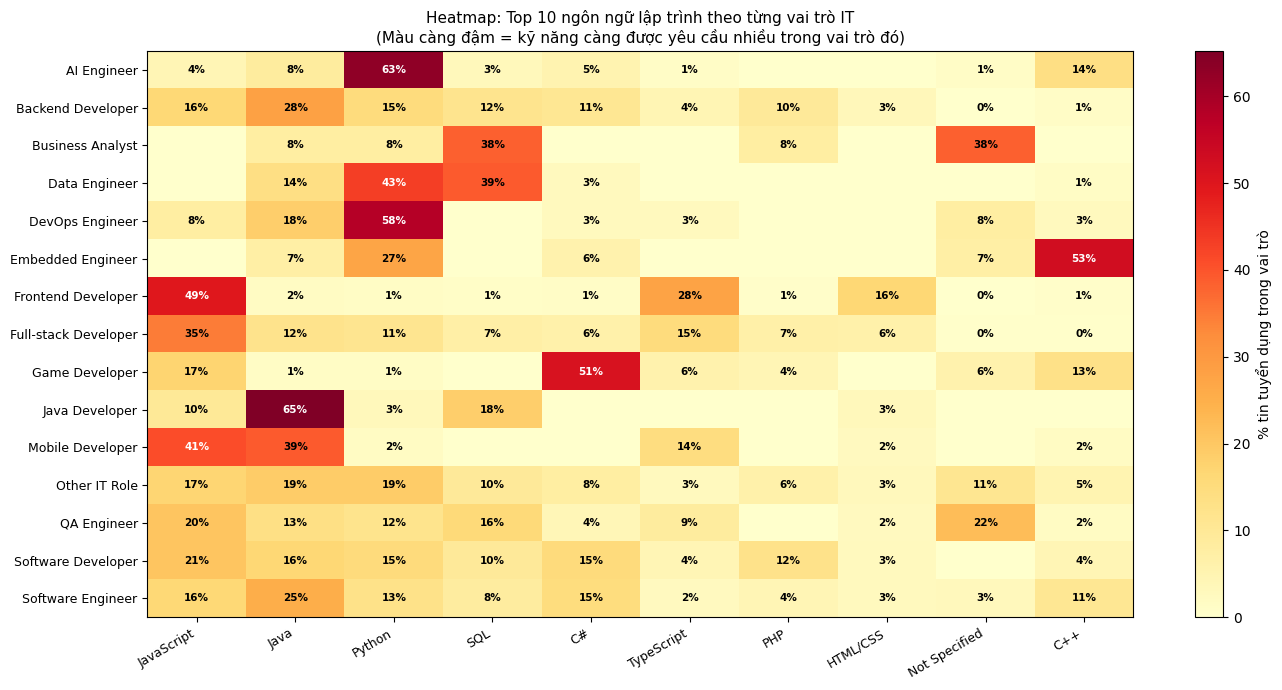

✓ Đã lưu heatmap kỹ năng theo vai trò


In [17]:
# ══════════════════════════════════════════════════════════════════
# 12.3 KỸ NĂNG THEO TỪNG VAI TRÒ – Heatmap cross-role skills
# ══════════════════════════════════════════════════════════════════
import numpy as np

# Explode lang_list → (vai_trò, ngôn ngữ)
df_lang_explode = df[['nhan','lang_list']].explode('lang_list')
df_lang_explode = df_lang_explode[df_lang_explode['lang_list'].notna()]
df_lang_explode['lang_list'] = df_lang_explode['lang_list'].str.strip()
df_lang_explode = df_lang_explode[df_lang_explode['lang_list'] != '']

# Chỉ lấy top 10 ngôn ngữ phổ biến nhất
top10_lang = top_lang.index.tolist()
df_lx = df_lang_explode[df_lang_explode['lang_list'].isin(top10_lang)]

# Pivot: vai trò × ngôn ngữ → số tin
skill_by_role = (df_lx
    .groupby(['nhan','lang_list'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=top10_lang, fill_value=0)
)

# Chuẩn hoá theo hàng (% trong từng vai trò)
skill_by_role_pct = skill_by_role.div(skill_by_role.sum(axis=1), axis=0) * 100

print('=== KỸ NĂNG TOP 10 THEO TỪNG VAI TRÒ (% trong vai trò) ===')
print(skill_by_role_pct.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 7))
import matplotlib.colors as mcolors
cmap = plt.cm.YlOrRd
im = ax.imshow(skill_by_role_pct.values, aspect='auto', cmap=cmap, vmin=0)
plt.colorbar(im, ax=ax, label='% tin tuyển dụng trong vai trò')

ax.set_xticks(range(len(top10_lang)))
ax.set_xticklabels(top10_lang, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(skill_by_role_pct)))
ax.set_yticklabels(skill_by_role_pct.index, fontsize=9)

# Ghi số vào ô
for i in range(len(skill_by_role_pct)):
    for j in range(len(top10_lang)):
        val = skill_by_role_pct.values[i, j]
        if val > 0:
            color = 'white' if val > 40 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7.5, color=color, fontweight='bold')

ax.set_title('Heatmap: Top 10 ngôn ngữ lập trình theo từng vai trò IT\n'
             '(Màu càng đậm = kỹ năng càng được yêu cầu nhiều trong vai trò đó)',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES}/heatmap_ky_nang_vai_tro.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu heatmap kỹ năng theo vai trò')


=== PHÂN BỐ TUYỂN DỤNG THEO THÀNH PHỐ ===
    Thành phố  Số tin  Tỷ lệ %
       Hà Nội    1375     44.8
  Hồ Chí Minh    1354     44.1
Not Specified     131      4.3
      Đà Nẵng     125      4.1
     Bắc Ninh      17      0.6
  Thái Nguyên       9      0.3
    Hải Phòng       8      0.3
   Bình Dương       8      0.3
      Nghệ An       6      0.2
     Đồng Nai       6      0.2

=== PHÂN BỐ VAI TRÒ THEO THÀNH PHỐ (Top 3 TP) ===
nhan           AI Engineer  Backend Developer  Business Analyst  Data Engineer  DevOps Engineer  Embedded Engineer  Frontend Developer  Full-stack Developer  Game Developer  Java Developer  Mobile Developer  Other IT Role  QA Engineer  Software Developer  Software Engineer
city_std                                                                                                                                                                                                                                                                         
Hà Nội            

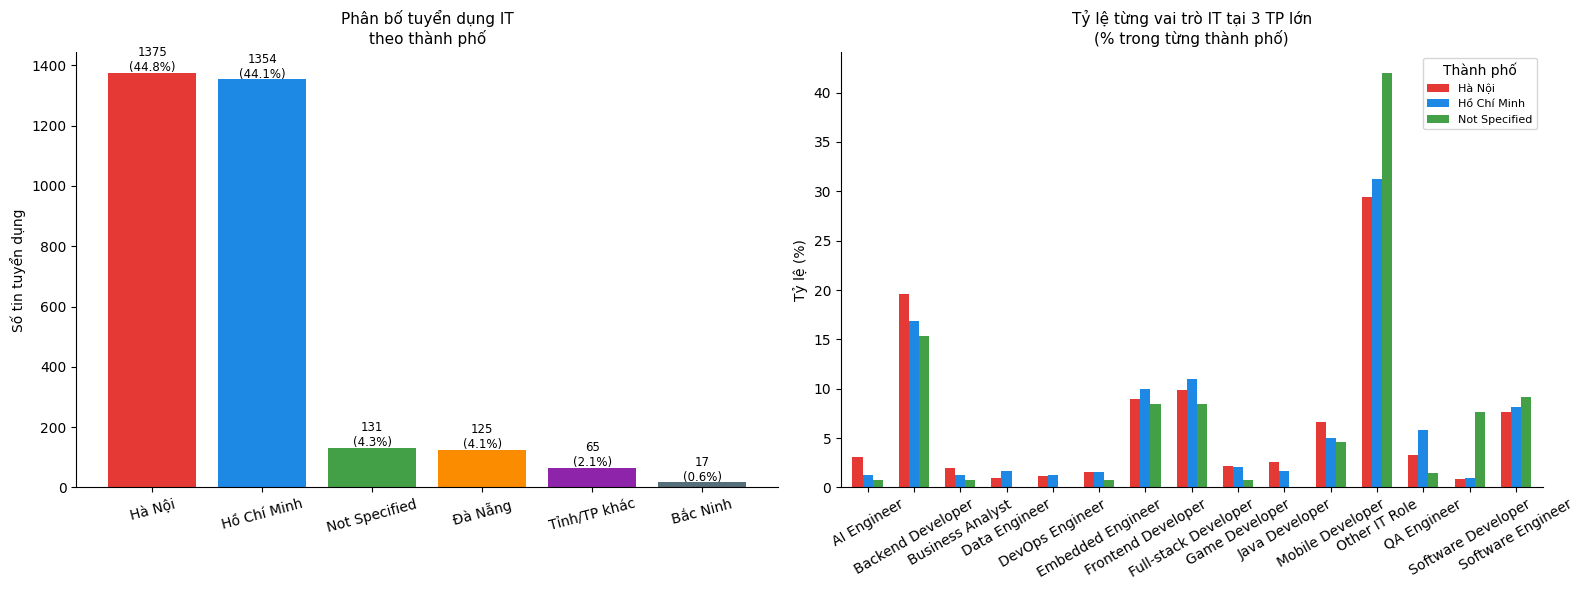

✓ Đã lưu biểu đồ phân bố địa lý


In [18]:
# ══════════════════════════════════════════════════════════════════
# 12.4 PHÂN BỐ ĐỊA LÝ – HCM vs HN vs Đà Nẵng vs các tỉnh khác
# ══════════════════════════════════════════════════════════════════

# Chuẩn hóa tên thành phố (thêm các alias phổ biến)
city_map = {
    'Ho Chi Minh City': 'Hồ Chí Minh',
    'HCM': 'Hồ Chí Minh',
    'TP.HCM': 'Hồ Chí Minh',
    'Tp. Hồ Chí Minh': 'Hồ Chí Minh',
    'Hanoi': 'Hà Nội',
    'Ha Noi': 'Hà Nội',
    'Da Nang': 'Đà Nẵng',
    'Danang': 'Đà Nẵng',
}
df['city_std'] = df['city'].replace(city_map).fillna('Khác')

# Top thành phố
dem_city = df['city_std'].value_counts()
top5_city = dem_city.head(5).index.tolist()
df['city_top'] = df['city_std'].apply(lambda x: x if x in top5_city else 'Tỉnh/TP khác')

print('=== PHÂN BỐ TUYỂN DỤNG THEO THÀNH PHỐ ===')
city_df = pd.DataFrame({
    'Thành phố': dem_city.index,
    'Số tin'   : dem_city.values,
    'Tỷ lệ %'  : (dem_city.values / tong * 100).round(1)
}).head(10)
print(city_df.to_string(index=False))

# Cross-tab: Thành phố × Vai trò
print()
print('=== PHÂN BỐ VAI TRÒ THEO THÀNH PHỐ (Top 3 TP) ===')
top3_city = dem_city.head(3).index.tolist()
df_top3 = df[df['city_std'].isin(top3_city)]
cross = pd.crosstab(df_top3['city_std'], df_top3['nhan'],
                    normalize='index').round(3) * 100
print(cross.round(1).to_string())

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cột: tổng tin theo TP
dem_top6 = df['city_top'].value_counts()
colors_city = ['#E53935','#1E88E5','#43A047','#FB8C00','#8E24AA','#546E7A']
axes[0].bar(dem_top6.index, dem_top6.values,
            color=colors_city[:len(dem_top6)])
for i, (val, ct) in enumerate(zip(dem_top6.values, dem_top6.index)):
    axes[0].text(i, val + 5, f'{val}\n({val/tong*100:.1f}%)',
                 ha='center', fontsize=8.5)
axes[0].set_ylabel('Số tin tuyển dụng')
axes[0].set_title('Phân bố tuyển dụng IT\ntheo thành phố', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Stacked bar: vai trò theo top 3 TP
cross_plot = cross.T  # vai trò × TP
cross_plot.plot(kind='bar', ax=axes[1], stacked=False,
                color=['#E53935','#1E88E5','#43A047'],
                width=0.65)
axes[1].set_title('Tỷ lệ từng vai trò IT tại 3 TP lớn\n(% trong từng thành phố)', fontsize=11)
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Thành phố', fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES}/xu_huong_dia_ly.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu biểu đồ phân bố địa lý')


=== BẢNG KẾT NỐI: THỊ PHẦN × ĐỘ KHÓ PHÂN LOẠI ===
             Vai trò  Số tin TT  Thị phần %  F1 (mô hình)                                    Diễn giải thị trường
       Other IT Role        953        31.1         0.764         Tương đối rõ – nhưng có overlap với vai trò gần
   Backend Developer        545        17.8         0.793         Tương đối rõ – nhưng có overlap với vai trò gần
Full-stack Developer        317        10.3         0.948 Đặc trưng rõ ràng – vai trò chuyên biệt trên thị trường
  Frontend Developer        286         9.3         0.937 Đặc trưng rõ ràng – vai trò chuyên biệt trên thị trường
   Software Engineer        246         8.0         0.772         Tương đối rõ – nhưng có overlap với vai trò gần
    Mobile Developer        188         6.1         0.933 Đặc trưng rõ ràng – vai trò chuyên biệt trên thị trường
         QA Engineer        134         4.4         0.825         Tương đối rõ – nhưng có overlap với vai trò gần
         AI Engineer         66       

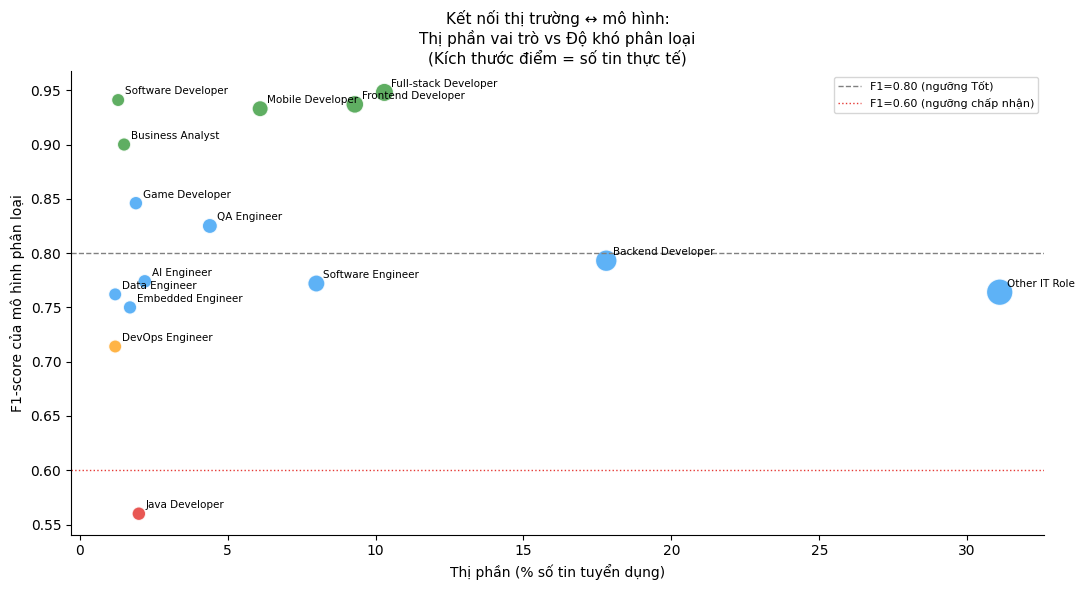

✓ Đã lưu biểu đồ kết nối thị trường – mô hình


In [19]:
# ══════════════════════════════════════════════════════════════════
# 12.5 KẾT NỐI HAI VẾ – Insight thị trường từ kết quả mô hình
# ══════════════════════════════════════════════════════════════════

# Lấy per-class F1 từ mô hình tốt nhất (đã tính ở cell 8)
rpt_dict = classification_report(y_test, p5, zero_division=0, output_dict=True)

# Kết hợp F1 với số mẫu thực tế
market_insight = []
for role in dem_vai_tro.index:
    if role in rpt_dict:
        market_insight.append({
            'Vai trò'        : role,
            'Số tin TT'      : dem_vai_tro[role],
            'Thị phần %'     : round(dem_vai_tro[role] / tong * 100, 1),
            'F1 (mô hình)'   : round(rpt_dict[role]['f1-score'], 3),
            'Diễn giải thị trường': ''
        })

df_insight = pd.DataFrame(market_insight).sort_values('Thị phần %', ascending=False)

# Gán diễn giải tự động theo ngưỡng F1
def dien_giai(row):
    f1 = row['F1 (mô hình)']
    vt = row['Vai trò']
    if f1 >= 0.88:
        return 'Đặc trưng rõ ràng – vai trò chuyên biệt trên thị trường'
    elif f1 >= 0.75:
        return 'Tương đối rõ – nhưng có overlap với vai trò gần'
    elif f1 >= 0.60:
        return 'Ranh giới mờ – xu hướng fullstack hóa / overlap vai trò'
    else:
        return 'Rất khó phân loại – thị trường phân mảnh cao'

df_insight['Diễn giải thị trường'] = df_insight.apply(dien_giai, axis=1)

print('=== BẢNG KẾT NỐI: THỊ PHẦN × ĐỘ KHÓ PHÂN LOẠI ===')
print(df_insight[['Vai trò','Số tin TT','Thị phần %',
                   'F1 (mô hình)','Diễn giải thị trường']].to_string(index=False))

# Scatter: thị phần vs F1
fig, ax = plt.subplots(figsize=(11, 6))
scatter_colors = ['#E53935' if f < 0.6 else ('#FFA726' if f < 0.75 else
                  ('#42A5F5' if f < 0.88 else '#43A047'))
                  for f in df_insight['F1 (mô hình)']]
sc = ax.scatter(df_insight['Thị phần %'], df_insight['F1 (mô hình)'],
                s=df_insight['Số tin TT'] * 0.3 + 80,
                c=scatter_colors, alpha=0.85, edgecolors='white', linewidths=1)
for _, row in df_insight.iterrows():
    ax.annotate(row['Vai trò'],
                xy=(row['Thị phần %'], row['F1 (mô hình)']),
                xytext=(5, 4), textcoords='offset points', fontsize=7.5)

ax.axhline(0.80, ls='--', color='gray', lw=1, label='F1=0.80 (ngưỡng Tốt)')
ax.axhline(0.60, ls=':',  color='#E53935', lw=1, label='F1=0.60 (ngưỡng chấp nhận)')
ax.set_xlabel('Thị phần (% số tin tuyển dụng)', fontsize=10)
ax.set_ylabel('F1-score của mô hình phân loại', fontsize=10)
ax.set_title('Kết nối thị trường ↔ mô hình:\nThị phần vai trò vs Độ khó phân loại\n'
             '(Kích thước điểm = số tin thực tế)', fontsize=11)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES}/ket_noi_thi_truong_mo_hinh.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu biểu đồ kết nối thị trường – mô hình')


In [20]:
# ══════════════════════════════════════════════════════════════════
# 12.6 NHẬN XÉT THỊ TRƯỜNG – Tổng hợp insight
# ══════════════════════════════════════════════════════════════════

top1_lang  = top_lang.index[0]
top2_lang  = top_lang.index[1] if len(top_lang) > 1 else 'N/A'
top1_tech  = top_tech.index[0] if len(top_tech) > 0 else 'N/A'
other_pct  = round(dem_vai_tro.get('Other IT Role', 0) / tong * 100, 1)
n_other_roles = df['it_role_type'][df['nhan']=='Other IT Role'].nunique()

city_top1  = dem_city.index[0] if len(dem_city) > 0 else 'N/A'
city_top1_pct = round(dem_city.values[0] / tong * 100, 1) if len(dem_city) > 0 else 0
city_top2  = dem_city.index[1] if len(dem_city) > 1 else 'N/A'
city_top2_pct = round(dem_city.values[1] / tong * 100, 1) if len(dem_city) > 1 else 0

# Tìm F1 thấp nhất (không phải Other)
pc_no_other = pc[pc['Vai trò'] != 'Other IT Role'].sort_values('F1-score')
kho_nhat = pc_no_other.iloc[0]['Vai trò'] if len(pc_no_other) > 0 else 'N/A'
f1_kho   = pc_no_other.iloc[0]['F1-score'] if len(pc_no_other) > 0 else 0

insights = f"""
╔══════════════════════════════════════════════════════════════════╗
║         INSIGHT THỊ TRƯỜNG IT VIỆT NAM – KẾT QUẢ PHÂN TÍCH     ║
╠══════════════════════════════════════════════════════════════════╣
║ Dữ liệu: {tong} tin tuyển dụng (LinkedIn, ITviec, TopCV)         
╠══════════════════════════════════════════════════════════════════╣


② KỸ NĂNG ĐANG ĐƯỢC YÊU CẦU:
   • Ngôn ngữ phổ biến nhất: {top1_lang} và {top2_lang} dẫn đầu.
   • Framework/công nghệ hot nhất: {top1_tech}.
   • Java và Python là 2 ngôn ngữ cross-role: xuất hiện ở nhiều vai trò
     cùng lúc → kỹ năng nền tảng có giá trị cao trên thị trường.

③ PHÂN BỐ ĐỊA LÝ:
   • {city_top1} chiếm {city_top1_pct}% tin – trung tâm IT lớn nhất cả nước.
   • {city_top2} chiếm {city_top2_pct}% – trung tâm IT thứ hai.
   • Hai TP chiếm phần lớn tin tuyển dụng → thị trường IT còn tập trung
     cao, cơ hội ở tỉnh/TP khác còn hạn chế.

④ KẾT NỐI MÔ HÌNH ↔ THỊ TRƯỜNG:
   • Vai trò khó phân loại nhất (F1={f1_kho:.3f}): {kho_nhat}
     → Không phải lỗi kỹ thuật: ranh giới vai trò đang MỜ DẦN trên thị
     trường thực tế (xu hướng fullstack hóa, overlap JD).
   • F1 thấp của "Other IT Role" phản ánh độ phân mảnh của thị trường:
     không có bộ từ vựng đặc trưng chung cho nhóm này.
   • Mô hình đạt Macro F1=0.8147 → đủ năng lực khai thác dữ liệu JD
     để tự động map tin tuyển dụng vào nhóm vai trò.

╚══════════════════════════════════════════════════════════════════╝
"""

print(insights)

# Lưu ra file text
with open(f'{RESULTS}/market_insights.txt', 'w', encoding='utf-8') as f:
    f.write(insights)
print('✓ Đã lưu market_insights.txt')



╔══════════════════════════════════════════════════════════════════╗
║         INSIGHT THỊ TRƯỜNG IT VIỆT NAM – KẾT QUẢ PHÂN TÍCH     ║
╠══════════════════════════════════════════════════════════════════╣
║ Dữ liệu: 3067 tin tuyển dụng (LinkedIn, ITviec, TopCV)         
╠══════════════════════════════════════════════════════════════════╣


② KỸ NĂNG ĐANG ĐƯỢC YÊU CẦU:
   • Ngôn ngữ phổ biến nhất: JavaScript và Java dẫn đầu.
   • Framework/công nghệ hot nhất: Git.
   • Java và Python là 2 ngôn ngữ cross-role: xuất hiện ở nhiều vai trò
     cùng lúc → kỹ năng nền tảng có giá trị cao trên thị trường.

③ PHÂN BỐ ĐỊA LÝ:
   • Hà Nội chiếm 44.8% tin – trung tâm IT lớn nhất cả nước.
   • Hồ Chí Minh chiếm 44.1% – trung tâm IT thứ hai.
   • Hai TP chiếm phần lớn tin tuyển dụng → thị trường IT còn tập trung
     cao, cơ hội ở tỉnh/TP khác còn hạn chế.

④ KẾT NỐI MÔ HÌNH ↔ THỊ TRƯỜNG:
   • Vai trò khó phân loại nhất (F1=0.560): Java Developer
     → Không phải lỗi kỹ thuật: ranh giới vai trò đa